# pyR0compute: examples

Symbolic computation of the basic reproduction number $R_0$ with the next-generation matrix method. Write the ODE model, say which compartments are infected, and every other symbol is recognised as a parameter.

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Yvan-BM-Git/pyR0compute/blob/main/examples/pyR0compute_examples.ipynb)

In [2]:
# In Colab or a new environment (use `pip install pyR0compute` once it is on PyPI):
# %pip install -q git+https://github.com/Yvan-BM-Git/pyR0compute
import sympy as sp
from pyr0compute import R0Model
sp.init_printing()

## 1. SEIR with vital dynamics

Only the equations and the infected compartments are given.

Parameters detected: (Lambda, beta, gamma, mu, sigma)
Disease-free equilibrium: {S: Lambda/mu, E: 0, I: 0, R: 0}


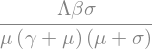

In [3]:
seir = R0Model("""
    dS/dt = Lambda - beta*S*I - mu*S
    dE/dt = beta*S*I - (sigma + mu)*E
    dI/dt = sigma*E - (gamma + mu)*I
    dR/dt = gamma*I - mu*R
""", infected=["E", "I"])

print("Parameters detected:", seir.parameters)
print("Disease-free equilibrium:", seir.dfe)
seir.R0

The whole computation, step by step:

In [4]:
print(seir.report())

pyR0compute: next-generation matrix method
Variables:  S, E, I, R
Infected:   E, I
Parameters: Lambda, beta, gamma, mu, sigma (detected automatically)

New-infection terms F_i (automatic):
  E: I*S*beta
  I: 0

Term classification:
  dE/dt  V  E*(-mu - sigma)   (negative term)
  dE/dt  F  I*S*beta   (transfer from uninfected S)
  dI/dt  V  E*sigma   (transfer from infected E)
  dI/dt  V  I*(-gamma - mu)   (negative term)

Transition terms V_i:
  E: E*mu + E*sigma
  I: -E*sigma + I*gamma + I*mu

Disease-free equilibrium:
  S = Lambda/mu
  E = 0
  I = 0
  R = 0

F =
⎡   Λ⋅β⎤
⎢0  ───⎥
⎢    μ ⎥
⎢      ⎥
⎣0   0 ⎦

V =
⎡μ + σ    0  ⎤
⎢            ⎥
⎣ -σ    γ + μ⎦

K = F V^-1 =
⎡      Λ⋅β⋅σ           Λ⋅β   ⎤
⎢─────────────────  ─────────⎥
⎢μ⋅(γ + μ)⋅(μ + σ)  μ⋅(γ + μ)⎥
⎢                            ⎥
⎣        0              0    ⎦

R0 =
      Λ⋅β⋅σ      
─────────────────
μ⋅(γ + μ)⋅(μ + σ)


The same report in LaTeX, rendered in the notebook (`style="markdown"`) or as code to paste into a paper (`seir.report_latex()`, or `standalone=True` for a file that compiles as is):

In [5]:
from IPython.display import Markdown, display
display(Markdown(seir.report_latex("markdown")))

## pyR0compute: next-generation matrix method

**Variables:** $S, E, I, R$  
**Infected compartments:** $E, I$  
**Parameters (detected automatically):** $\Lambda, \beta, \gamma, \mu, \sigma$

### Model

$$
\begin{aligned}
\frac{dS}{dt} &= - I S \beta + \Lambda - S \mu \\
\frac{dE}{dt} &= - E \left(\mu + \sigma\right) + I S \beta \\
\frac{dI}{dt} &= E \sigma - I \left(\gamma + \mu\right) \\
\frac{dR}{dt} &= I \gamma - R \mu
\end{aligned}
$$

### New-infection terms (automatic)

$$
\begin{aligned}
\mathcal{F}_{E} &= I S \beta \\
\mathcal{F}_{I} &= 0
\end{aligned}
$$

### Term classification

| Equation | Term | Class | Reason |
|---|---|:---:|---|
| $dE/dt$ | $E \left(- \mu - \sigma\right)$ | $\mathcal{V}$ | negative term |
| $dE/dt$ | $I S \beta$ | $\mathcal{F}$ | transfer from uninfected S |
| $dI/dt$ | $E \sigma$ | $\mathcal{V}$ | transfer from infected E |
| $dI/dt$ | $I \left(- \gamma - \mu\right)$ | $\mathcal{V}$ | negative term |

### Transition terms

$$
\begin{aligned}
\mathcal{V}_{E} &= E \mu + E \sigma \\
\mathcal{V}_{I} &= - E \sigma + I \gamma + I \mu
\end{aligned}
$$

### Disease-free equilibrium

$$
\begin{aligned}
S &= \frac{\Lambda}{\mu} \\
E &= 0 \\
I &= 0 \\
R &= 0
\end{aligned}
$$

### Next-generation matrix

$$
\begin{aligned}
F &= \begin{bmatrix}0 & \frac{\Lambda \beta}{\mu}\\0 & 0\end{bmatrix} \\
V &= \begin{bmatrix}\mu + \sigma & 0\\- \sigma & \gamma + \mu\end{bmatrix} \\
K = F V^{-1} &= \begin{bmatrix}\frac{\Lambda \beta \sigma}{\mu \left(\gamma + \mu\right) \left(\mu + \sigma\right)} & \frac{\Lambda \beta}{\mu \left(\gamma + \mu\right)}\\0 & 0\end{bmatrix}
\end{aligned}
$$

Only $E$ receive new infections, so $\mathcal{R}_0$ is the spectral radius of the next-generation matrix with small domain:

$$
\begin{aligned}
K_{\text{small}} &= \begin{bmatrix}\frac{\Lambda \beta \sigma}{\mu \left(\gamma + \mu\right) \left(\mu + \sigma\right)}\end{bmatrix}
\end{aligned}
$$

### Basic reproduction number

$$
\begin{aligned}
\mathcal{R}_0 = \rho\left(F V^{-1}\right) &= \frac{\Lambda \beta \sigma}{\mu \left(\gamma + \mu\right) \left(\mu + \sigma\right)}
\end{aligned}
$$

In [7]:
print(seir.report_latex())

\section*{pyR0compute: next-generation matrix method}

\textbf{Variables:} $S, E, I, R$ \\
\textbf{Infected compartments:} $E, I$ \\
\textbf{Parameters (detected automatically):} $\Lambda, \beta, \gamma, \mu, \sigma$

\subsection*{Model}

\begin{align*}
\frac{dS}{dt} &= - I S \beta + \Lambda - S \mu \\
\frac{dE}{dt} &= - E \left(\mu + \sigma\right) + I S \beta \\
\frac{dI}{dt} &= E \sigma - I \left(\gamma + \mu\right) \\
\frac{dR}{dt} &= I \gamma - R \mu
\end{align*}

\subsection*{New-infection terms (automatic)}

\begin{align*}
\mathcal{F}_{E} &= I S \beta \\
\mathcal{F}_{I} &= 0
\end{align*}

\subsection*{Term classification}

\begin{tabular}{llcl}
\hline
Equation & Term & Class & Reason \\
\hline
$dE/dt$ & $E \left(- \mu - \sigma\right)$ & $\mathcal{V}$ & negative term \\
$dE/dt$ & $I S \beta$ & $\mathcal{F}$ & transfer from uninfected S \\
$dI/dt$ & $E \sigma$ & $\mathcal{V}$ & transfer from infected E \\
$dI/dt$ & $I \left(- \gamma - \mu\right)$ & $\mathcal{V}$ & negative term \\


Matrices $F$, $V$ and $K = FV^{-1}$ are available as SymPy objects:

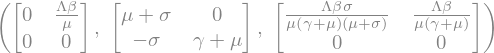

In [8]:
seir.F, seir.V, seir.K

### Sensitivity indices

$\Upsilon_p = \dfrac{\partial R_0}{\partial p}\dfrac{p}{R_0}$: a 1% increase in $p$ changes $R_0$ by $\Upsilon_p$%.

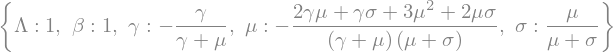

In [9]:
seir.sensitivity_indices()

In [10]:
values = {"Lambda": 10, "beta": 0.001, "sigma": 0.2, "gamma": 0.1, "mu": 0.02}
print("R0 =", seir.R0_numeric(values))
seir.sensitivity_indices(values)

R0 = 3.787878787878788


## 2. Classic SIR (closed population)

Without births the disease-free equilibrium is not unique, so the susceptible population at the DFE is given.

In [12]:
sir = R0Model({"S": "-beta*S*I/N",
               "I": "beta*S*I/N - gamma*I",
               "R": "gamma*I"}, infected=["I"], dfe={"S": "N"})
sir.R0

Without `dfe`, the error says exactly what is missing:

In [13]:
try:
    R0Model({"S": "-beta*S*I/N", "I": "beta*S*I/N - gamma*I", "R": "gamma*I"}, infected=["I"])
except Exception as e:
    print(type(e).__name__, "->", e)

DiseaseFreeEquilibriumError -> The disease-free value of ['S'] is not determined by the equations (e.g. a closed population without births). Provide it with dfe={'S': ...}.


## 3. Vector-borne disease: Ross-Macdonald model

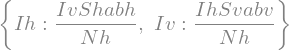

In [14]:
rm = R0Model("""
    dSh/dt = Lh - a*bh*Sh*Iv/Nh - muh*Sh
    dIh/dt = a*bh*Sh*Iv/Nh - (gamma + muh)*Ih
    dRh/dt = gamma*Ih - muh*Rh
    dSv/dt = Lv - a*bv*Sv*Ih/Nh - muv*Sv
    dIv/dt = a*bv*Sv*Ih/Nh - muv*Iv
""", infected=["Ih", "Iv"])
rm.new_infections

In [12]:
rm.K

⎡                   Lh⋅a⋅bh  ⎤
⎢       0          ──────────⎥
⎢                  Nh⋅muh⋅muv⎥
⎢                            ⎥
⎢    Lv⋅a⋅bv                 ⎥
⎢────────────────      0     ⎥
⎣Nh⋅muv⋅(γ + muh)            ⎦

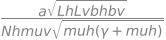

In [13]:
rm.R0

## 4. Host-vector model with human-to-human transmission and logistic vectors

The total human population is an auxiliary definition. The model has two disease-free equilibria (with and without vectors); the one with vectors is chosen and both are kept.

/tmp/ipykernel_269/4047650626.py:1: UserWarning: 2 disease-free equilibria were found; using the one with the most non-zero compartments: {'Mv': -kappa*(mum + omega - phiv)/phiv, 'Rh': Deltah*theta/(muh**2 + muh*theta), 'Sh': Deltah/(muh + theta), 'Sv': -kappa*omega*(mum + omega - phiv)/(phiv*(muv + zeta))}. Pass dfe={...} to choose another one (all are in model.dfe_candidates).
  hv = R0Model("""


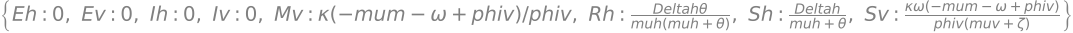

In [14]:
hv = R0Model("""
    Nh = Sh + Eh + Ih + Rh
    dSh/dt = Deltah - delta*alphahv*Sh*Iv/Nh - beta*alphahh*Sh*Ih/Nh - (theta + muh)*Sh
    dEh/dt = delta*alphahv*Sh*Iv/Nh + beta*alphahh*Sh*Ih/Nh - (sigma + muh)*Eh
    dIh/dt = sigma*Eh - (gamma + muh)*Ih
    dRh/dt = gamma*Ih - muh*Rh + theta*Sh
    dMv/dt = phiv*Mv*(1 - Mv/kappa) - (omega + mum)*Mv
    dSv/dt = omega*Mv - delta*alphavh*Sv*Ih/Nh - (muv + zeta)*Sv
    dEv/dt = delta*alphavh*Sv*Ih/Nh - (psi + muv + zeta)*Ev
    dIv/dt = psi*Ev - (muv + zeta)*Iv
""", infected=["Eh", "Ih", "Ev", "Iv"])
hv.dfe

Only $E_h$ and $E_v$ receive new infections, so $R_0$ is the spectral radius of the $2\times 2$ next-generation matrix with small domain:

In [15]:
hv.next_generation_matrix_small

⎡             alphahh⋅β⋅muh⋅σ                        alphahv⋅δ⋅muh⋅ψ         ⎤
⎢      ─────────────────────────────        ─────────────────────────────────⎥
⎢      (γ + muh)⋅(muh + σ)⋅(muh + θ)        (muh + θ)⋅(muv + ζ)⋅(muv + ψ + ζ)⎥
⎢                                                                            ⎥
⎢ -alphavh⋅δ⋅κ⋅muh⋅ω⋅σ⋅(mum + ω - phiv)                                      ⎥
⎢─────────────────────────────────────────                  0                ⎥
⎣Deltah⋅phiv⋅(γ + muh)⋅(muh + σ)⋅(muv + ζ)                                   ⎦

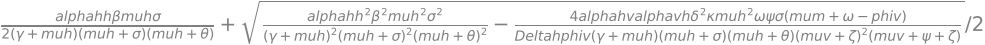

In [16]:
hv.R0

## 5. Within-host model: target cells, infected cells and virus

In [17]:
tiv = R0Model("""
    dT/dt = s - d*T - beta*T*V
    dI/dt = beta*T*V - delta*I
    dV/dt = p*I - c*V
""", infected=["I", "V"])
tiv.R0

## 6. van den Driessche & Watmough (2002), treatment model (§4.1)

$p r_2 I$ (treatment failure) is correctly classified as a transition, not a new infection.

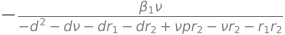

In [18]:
tb = R0Model("""
    N = S + E + I + T
    dE/dt = beta1*S*I/N + beta2*T*I/N - (d + nu + r1)*E + p*r2*I
    dI/dt = nu*E - (d + r2)*I
    dS/dt = b - d*S - beta1*S*I/N
    dT/dt = -d*T + r1*E + q*r2*I - beta2*T*I/N
""", infected=["E", "I"])
tb.R0

## 7. Two strains with superinfection

Which strain dominates depends on the parameters, so $R_0$ is the maximum of the strain-specific numbers.

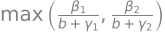

In [19]:
import warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    two = R0Model("""
        dI1/dt = beta1*I1*S - (b + gamma1)*I1 + nu*I1*I2
        dI2/dt = beta2*I2*S - (b + gamma2)*I2 - nu*I1*I2
        dS/dt = b - b*S + gamma1*I1 + gamma2*I2 - (beta1*I1 + beta2*I2)*S
    """, infected=["I1", "I2"])
    R0 = two.R0
R0

## 8. Your own model

Replace the equations and the infected compartments. If the automatic split into new infections and transitions is not the one you want, use `new_infections={...}`; to fix the disease-free equilibrium, use `dfe={...}`.

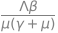

In [20]:
model = R0Model("""
    dS/dt = Lambda - beta*S*I - mu*S
    dI/dt = beta*S*I - (gamma + mu)*I
""", infected=["I"])
model.R0

In [21]:
print(model.latex())

\frac{\Lambda \beta}{\mu \left(\gamma + \mu\right)}
